<a href="https://colab.research.google.com/github/koniitinomiya-prog/crack-detection/blob/main/Crack_detection_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crack Detection CNN

コンクリートのひび割れ検出を行うCNNモデルです。

授業のFashion MNISTと同じ流れで実装します：
1. Data Prep
2. Define Model
3. Set Optimization Parameters
4. Train Model
5. Evaluate Model

**データセット**: SDNET2018
- 56,000枚以上のコンクリート画像（ひびあり／なし）
- Bridge decks (D), Walls (W), Pavements (P)
- 各画像は256×256px


# VS Codeで編集テスト

## 0. Setup

In [47]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path    = "/content/drive/MyDrive/HODL/SDNET2018.zip"
extract_dir = "/content/D"   # ZIPはトップレベルフォルダなしで展開される

if not os.path.exists(extract_dir):
    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall("/content")
    print("Done!")
else:
    print("Already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already extracted.


In [48]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
from pathlib import Path

# 再現性のためにシードを固定（授業と同じ）
keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


In [49]:
# ★ 割合を変更したい場合はここだけ編集
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10

base_dir = Path("/content/crack-data")

# D（Bridge deck）・W（Wall）・P（Pavement）の3カテゴリすべてを使う
# (親ディレクトリ, ひびありフォルダ, ひびなしフォルダ)
categories = [
    (Path("/content/D"), "CD", "UD"),
    (Path("/content/W"), "CW", "UW"),
    (Path("/content/P"), "CP", "UP"),
]

for cat_dir, cracked_folder, uncracked_folder in categories:
    for src_folder, label in [(cracked_folder, "cracked"), (uncracked_folder, "uncracked")]:
        fnames = sorted(os.listdir(cat_dir / src_folder))
        n = len(fnames)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        splits = {
            "train":      fnames[:n_train],
            "validation": fnames[n_train : n_train + n_val],
            "test":       fnames[n_train + n_val :],
        }
        for split, names in splits.items():
            dst_dir = base_dir / split / label
            os.makedirs(dst_dir, exist_ok=True)
            for fname in names:
                # D/W/Pで同名ファイルが存在するためフォルダ名をプレフィックスに付ける
                dst_fname = f"{src_folder}_{fname}"
                shutil.copyfile(
                    src=cat_dir / src_folder / fname,
                    dst=dst_dir / dst_fname
                )

for split in ("train", "validation", "test"):
    for label in ("cracked", "uncracked"):
        n = len(list((base_dir / split / label).glob("*.jpg")))
        print(f"{split}/{label}: {n} images")


train/cracked: 7354 images
train/uncracked: 41440 images
validation/cracked: 1049 images
validation/uncracked: 5918 images
test/cracked: 2106 images
test/uncracked: 11845 images


In [50]:
IMG_SIZE = 64

train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'validation',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

# クラス名確認（アルファベット順: cracked=0, uncracked=1）
print("Class names:", train_dataset.class_names)

# 正規化 (0-255 → 0-1) とラベル反転（cracked=1, uncracked=0 に統一）
# image_dataset_from_directory はアルファベット順でラベルを付けるため
# "cracked"=0, "uncracked"=1 となるので 1 - labels で反転する
def preprocess(images, labels):
    return images / 255.0, 1 - labels

train_dataset      = train_dataset.map(preprocess)
validation_dataset = validation_dataset.map(preprocess)
test_dataset       = test_dataset.map(preprocess)

Found 48794 files belonging to 2 classes.
Found 6967 files belonging to 2 classes.
Found 13951 files belonging to 2 classes.
Class names: ['cracked', 'uncracked']


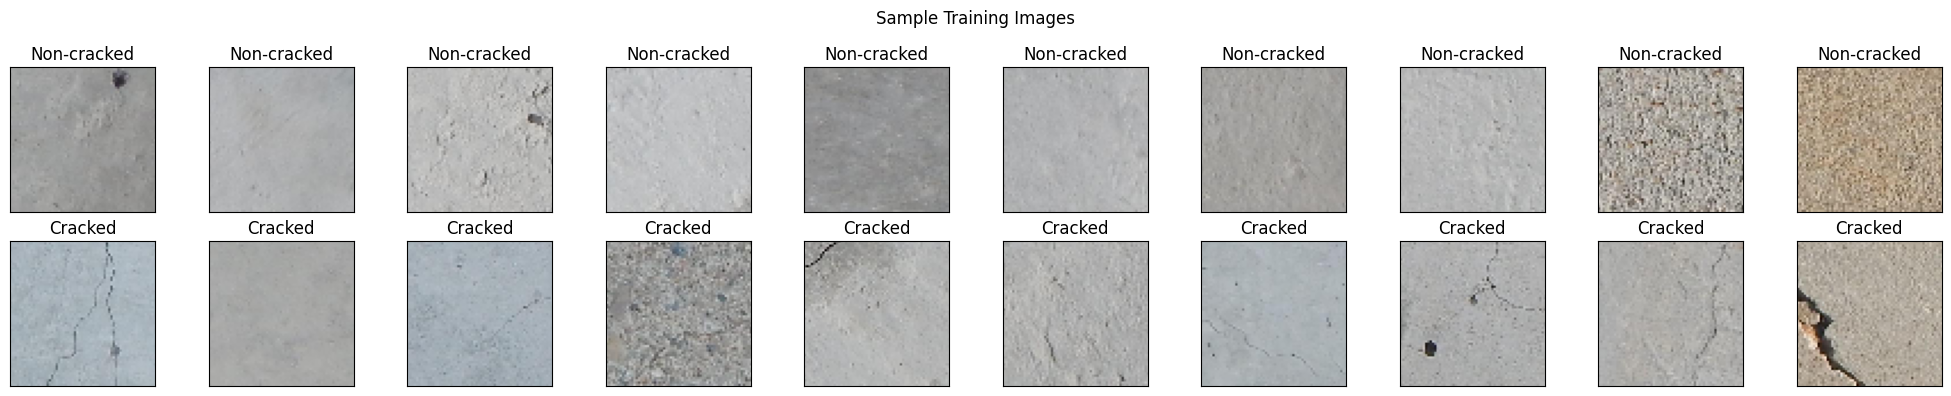

In [51]:
# ひびあり・なしを10枚ずつ表示
labels_map = ["Non-cracked", "Cracked"]
N = 10

import random
random.seed(42)

def load_samples(folder, n):
    fnames = random.sample(os.listdir(folder), n)
    imgs = []
    for fname in fnames:
        img = keras.utils.load_img(str(folder / fname), target_size=(IMG_SIZE, IMG_SIZE))
        imgs.append(keras.utils.img_to_array(img) / 255.0)
    return imgs

noncracked_imgs = load_samples(base_dir / 'train' / 'uncracked', N)
cracked_imgs    = load_samples(base_dir / 'train' / 'cracked',   N)

sample_imgs   = noncracked_imgs + cracked_imgs
sample_labels = [0] * N + [1] * N

figure = plt.figure(figsize=(20, 4))
for i, (img, lbl) in enumerate(zip(sample_imgs, sample_labels)):
    ax = figure.add_subplot(2, N, i+1, xticks=[], yticks=[])
    ax.imshow(img)
    ax.set_title(labels_map[lbl])
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 2. Define Model

授業のFashion MNISTとほぼ同じ構造です。

違いは：
- 入力: `(64, 64, 3)` ← カラー画像（RGBの3チャンネル）
- 出力: `Dense(1, sigmoid)` ← 2クラス分類（ひびあり／なし）

```
Fashion MNIST:   Dense(10, softmax)  ← 10クラス分類
Crack Detection: Dense(1, sigmoid)   ← 2クラス分類
```

In [68]:
input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # (64, 64, 3)

# ==============================
# 【追加】Data Augmentation
# 訓練時だけランダムに画像を変形して水増しする
# → 同じ画像を何度も見せず過学習を防ぐ
# ※ model.predict()時は自動でOFFになる
# ==============================
x = keras.layers.RandomFlip("horizontal_and_vertical")(input)  # 左右・上下反転
x = keras.layers.RandomRotation(0.15)(x)                       # ±15%回転
x = keras.layers.RandomZoom(0.1)(x)                            # ±10%拡縮

# ==============================
# 第1 Conv Block
# ==============================
x = keras.layers.Conv2D(32, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)

# ==============================
# 第2 Conv Block
# ==============================
x = keras.layers.Conv2D(64, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)

# ==============================
# 第3 Conv Block
# ==============================
x = keras.layers.Conv2D(128, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)

# ==============================
# 第2 Conv Block
# ==============================
x = keras.layers.Conv2D(256, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)



# ==============================
# 全結合層
# ==============================
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)

# ==============================
# 出力層（sigmoid: 0〜1の確率を出力、0.5以上→ひびあり）
# ==============================
output = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(input, output)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,439,425 (5.49 MB)

 Trainable params: 1,438,465 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Set Optimization Parameters

授業との違い：
- 損失関数: `binary_crossentropy`（2クラスなのでbinary）
  - 授業: `sparse_categorical_crossentropy`（10クラス）
- メトリクス: `accuracy` に加えて `Recall` も監視

In [69]:
# 授業と同じplot関数（loss と accuracy）
def plot_loss_curves(history):
    plt.clf()
    plt.plot(history.history["loss"],     "bo", label="Training loss")
    plt.plot(history.history["val_loss"], "b",  label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_acc_curves(history):
    plt.clf()
    plt.plot(history.history["accuracy"],     "bo", label="Training acc")
    plt.plot(history.history["val_accuracy"], "b",  label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def plot_recall_curves(history):
    plt.clf()
    plt.plot(history.history["recall"],     "ro", label="Training recall")
    plt.plot(history.history["val_recall"], "r",  label="Validation recall")
    plt.axhline(y=0.95, color='gray', linestyle='--', label="Target (0.95)")
    plt.title("Training and validation recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

In [70]:
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),       # ひび割れの見逃し率監視
        keras.metrics.Precision(name='precision')  # 誤検出率監視
    ]
)

In [71]:
# ひびあり(cracked=1)が少ない分、損失を重く補正する
n_cracked   = len(list((base_dir / "train" / "cracked").glob("*.jpg")))
n_uncracked = len(list((base_dir / "train" / "uncracked").glob("*.jpg")))
total = n_cracked + n_uncracked

class_weight = {
    0: total / (2 * n_uncracked),  # uncracked
    1: total / (2 * n_cracked),    # cracked（少ない方を重く）
}

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[early_stop],
    class_weight=class_weight  # クラス不均衡の補正
)

Epoch 1/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.6013 - loss: 0.7146 - precision: 0.2104 - recall: 0.5944 - val_accuracy: 0.6565 - val_loss: 0.6295 - val_precision: 0.2437 - val_recall: 0.6092
Epoch 2/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6543 - loss: 0.6340 - precision: 0.2479 - recall: 0.6348 - val_accuracy: 0.7178 - val_loss: 0.5698 - val_precision: 0.2706 - val_recall: 0.5157
Epoch 3/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6840 - loss: 0.6125 - precision: 0.2703 - recall: 0.6439 - val_accuracy: 0.7593 - val_loss: 0.4901 - val_precision: 0.2767 - val_recall: 0.3708
Epoch 4/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6953 - loss: 0.5973 - precision: 0.2845 - recall: 0.6680 - val_accuracy: 0.7092 - val_loss: 0.5789 - val_precision: 0.2750 - val_recall: 0.5691
Epoch 5/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.7145 - loss: 0.5803 - precision: 0.3018 - recall: 0.6771 - val_accuracy: 0

## 4. Train the Model

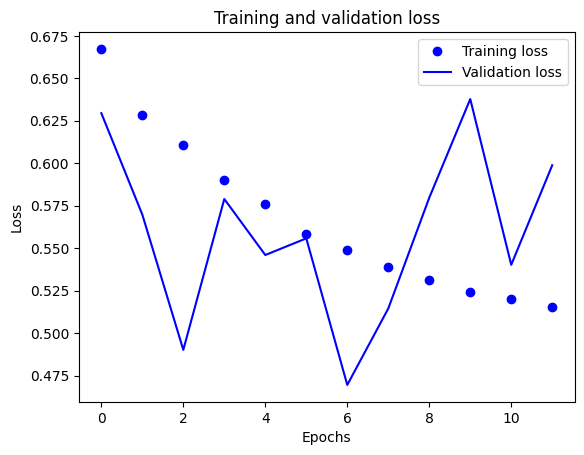

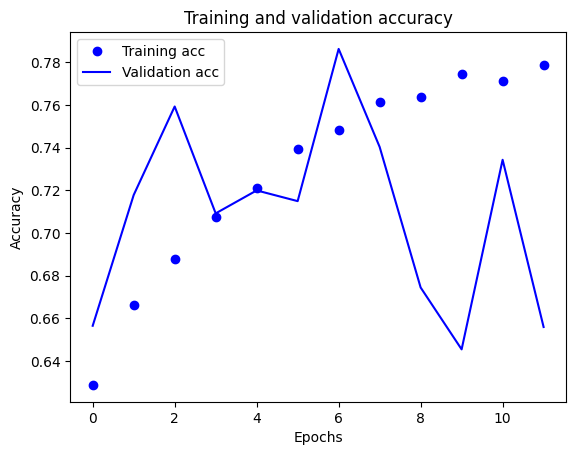

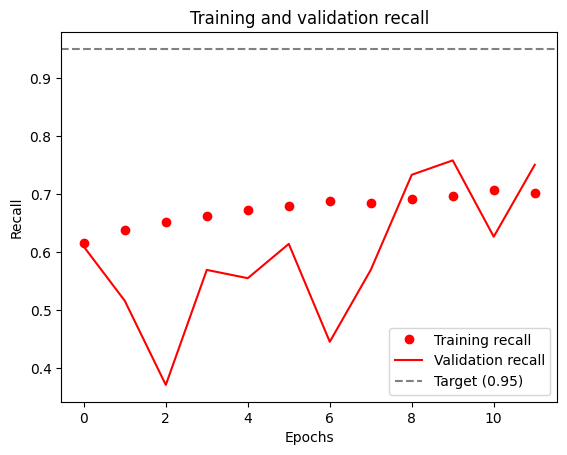

In [72]:
# 授業と同じ：lossとaccuracyのグラフ
plot_loss_curves(history)
plot_acc_curves(history)

# ひび割れ検出特有：Recallのグラフ
plot_recall_curves(history)

## 5. Evaluate the Model

In [73]:
# 授業と同じ：model.evaluate()
score = model.evaluate(test_dataset)
print("Test loss:     ", score[0])
print("Test accuracy: ", score[1])
print("Test recall:   ", score[2])
print("Test precision:", score[3])

436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8406 - loss: 0.4841 - precision: 0.4607 - recall: 0.4391
Test loss:      0.4865536689758301
Test accuracy:  0.838004469871521
Test recall:    0.43209877610206604
Test precision: 0.4609929025173187


In [74]:
# データセットから正解ラベルと予測結果を収集
y_prob = model.predict(test_dataset).flatten()
y_pred = (y_prob >= 0.75).astype(int)

# データセットから真のラベルを収集
y_test = np.concatenate([y.numpy() for _, y in test_dataset])
x_test_list = [x.numpy() for x, _ in test_dataset]
x_test = np.concatenate(x_test_list)

misses = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(misses)} / {len(y_test)} images")

436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Misclassified: 2445 / 13951 images


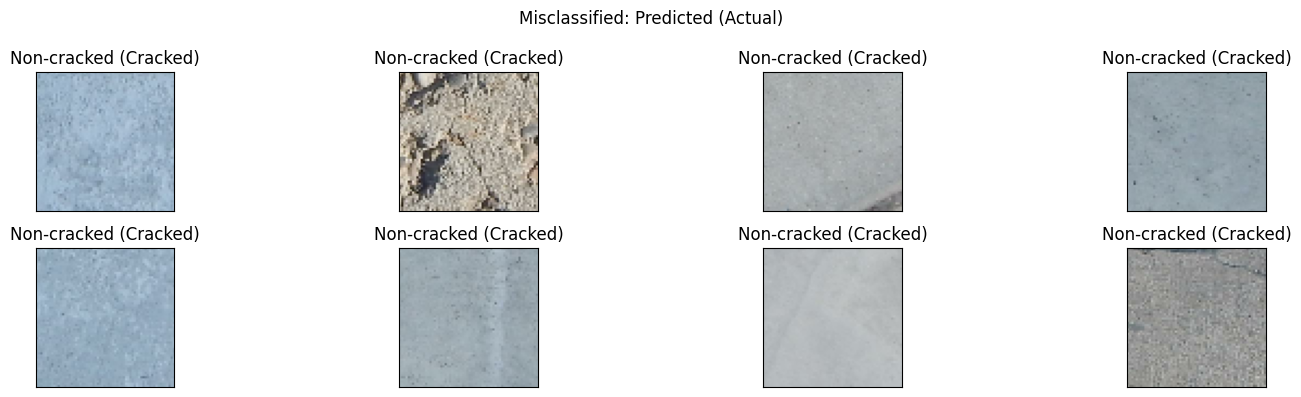

In [75]:
# 間違えた画像を表示（授業と同じスタイル）
sample = np.random.choice(misses, size=min(8, len(misses)), replace=False)
figure = plt.figure(figsize=(16, 4))
for i, idx in enumerate(sample):
    ax = figure.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    ax.imshow(x_test[idx])
    ax.set_title("{} ({})".format(
        labels_map[y_pred[idx]],
        labels_map[y_test[idx]]
    ))
plt.suptitle("Misclassified: Predicted (Actual)")
plt.tight_layout()
plt.show()

## 6. Bonus: ヒートマップで「どこにひびがあるか」を可視化

大きな壁の写真を256×256に切り分けて、ひびがある場所をヒートマップで表示します。

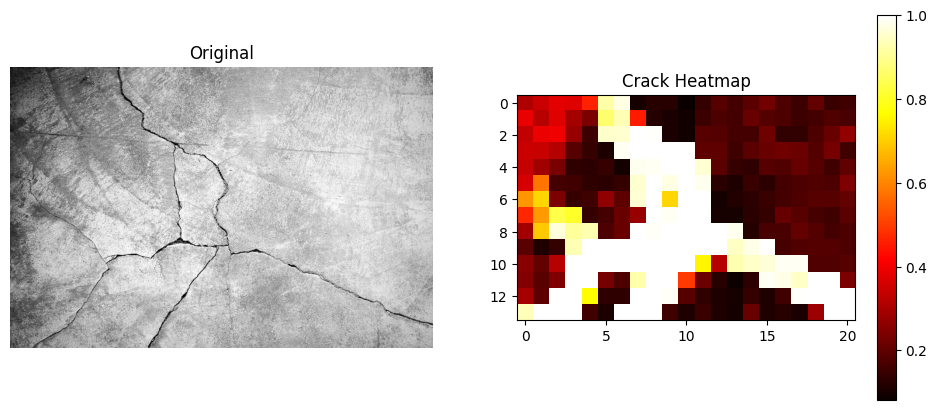

In [76]:
import math
from PIL import Image

def crack_heatmap(image_path, model, tile=IMG_SIZE, stride=8):
    """
    stride を小さくするほど細かいヒートマップになる（stride=8で4倍細かい）
    全cropをまとめてbatch predictするため高速
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    nx = math.floor((W - tile) / stride) + 1
    ny = math.floor((H - tile) / stride) + 1

    # 全cropを一括で切り出す
    crops = []
    for iy in range(ny):
        for ix in range(nx):
            x0, y0 = ix * stride, iy * stride
            crop = img.crop((x0, y0, x0 + tile, y0 + tile))
            crops.append(np.array(crop) / 255.0)

    # バッチpredictで高速化（1枚ずつより大幅に速い）
    crops = np.array(crops)  # (N, tile, tile, 3)
    probs = model.predict(crops, batch_size=64, verbose=0).flatten()
    heat = probs.reshape(ny, nx)

    # ヒートマップを元画像サイズにリサイズ（バイリニア補間）
    heat_pil = Image.fromarray((heat * 255).astype(np.uint8))
    heat_resized = np.array(heat_pil.resize((W, H), Image.BILINEAR)) / 255.0

    return img, heat_resized


large_img_path = "/content/drive/MyDrive/your_wall_photo.jpg"  # ★実際のファイル名に変える
img, heat = crack_heatmap(large_img_path, model, tile=IMG_SIZE, stride=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title("Original")

im = axes[1].imshow(heat, cmap="hot", vmin=0, vmax=1)
axes[1].axis("off")
axes[1].set_title("Crack Heatmap")
plt.colorbar(im, ax=axes[1])

# 元画像にヒートマップを重ねて表示
axes[2].imshow(img)
axes[2].imshow(heat, cmap="hot", alpha=0.5, vmin=0, vmax=1)
axes[2].axis("off")
axes[2].set_title("Overlay")

plt.tight_layout()
plt.show()

## 7. Transfer Learning（EfficientNetB0）

自作CNNとの比較のため、ImageNetで事前学習済みの **EfficientNetB0** を使った転移学習を実装します。

**2フェーズ学習の流れ**

| フェーズ | バックボーン | 学習率 | 目的 |
|---|---|---|---|
| フェーズ1（特徴抽出） | 全層凍結 | 1e-3 | 分類頭のみ素早く収束させる |
| フェーズ2（ファインチューニング） | 上位20層だけ解凍 | 1e-5 | ひび割れドメインに微調整 |

フェーズ2はフェーズ1の学習済み重みをそのまま引き継ぎます。

### 7-1. データセット準備（224×224）

EfficientNetB0 の推奨入力サイズ **224×224** でデータを読み込みます。

自作CNNは64×64でしたが、EfficientNetB0はImageNetで224×224を前提に学習されているため、推奨サイズに合わせます。  
また、EfficientNetB0には **内部スケーリング処理が組み込まれている** ため、画像を0〜255のまま渡します（`/255.0`不要）。

In [ ]:

IMG_SIZE_TL = 224  # EfficientNetB0 の推奨入力サイズ

# EfficientNetB0 は内部にスケーリング処理を含む（0〜255の入力をそのまま渡す）
def preprocess_tl(images, labels):
    return images, 1 - labels  # ラベルのみ反転（cracked=1, uncracked=0）

train_dataset_tl = keras.utils.image_dataset_from_directory(
    base_dir / "train",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32
).map(preprocess_tl)

validation_dataset_tl = keras.utils.image_dataset_from_directory(
    base_dir / "validation",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32
).map(preprocess_tl)

test_dataset_tl = keras.utils.image_dataset_from_directory(
    base_dir / "test",
    image_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32
).map(preprocess_tl)

print(f"入力サイズ: {IMG_SIZE_TL}×{IMG_SIZE_TL}  （自作CNNは64×64）")


### 7-2. モデル定義（バックボーン凍結）

```
EfficientNetB0（ImageNet学習済み）
  ↓ 全層凍結（trainable=False）
GlobalAveragePooling2D
  ↓
Dense(256, relu)  ←  ここだけ学習する
Dropout(0.5)
Dense(1, sigmoid)
```

ポイント：`base_model(x, training=False)` で BatchNorm を推論モードに固定する

In [ ]:

# ==============================
# バックボーン（ImageNet学習済み、全層凍結）
# ==============================
base_model = keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,           # 分類頭を除いた特徴抽出部分のみ
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3)
)
base_model.trainable = False     # 全層凍結

print(f"EfficientNetB0 総層数: {len(base_model.layers)}")
print(f"Non-trainable params: {base_model.count_params():,}")

# ==============================
# モデル構築
# ==============================
inputs = keras.Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))

# Data Augmentation（自作CNNと同じ設定）
x = keras.layers.RandomFlip("horizontal_and_vertical")(inputs)
x = keras.layers.RandomRotation(0.15)(x)
x = keras.layers.RandomZoom(0.1)(x)

# バックボーン（training=False で BatchNorm を推論モード固定）
x = base_model(x, training=False)

# 分類頭
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model_fe = keras.Model(inputs, outputs)

trainable   = sum(p.numpy().size for p in model_fe.trainable_variables)
nontrainable = sum(p.numpy().size for p in model_fe.non_trainable_variables)
print(f"\nTrainable params (頭のみ): {trainable:,}")
print(f"Non-trainable params:      {nontrainable:,}")


### 7-3. フェーズ1学習：バックボーン凍結（特徴抽出）

バックボーンの重みは固定したまま、分類頭のみ学習します。

- 学習率: `1e-3`（頭だけなので高めでOK）
- EarlyStopping で val_loss を監視

In [ ]:

model_fe.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # 頭だけ学習するので高めのLR
    metrics=[
        "accuracy",
        keras.metrics.Recall(name="recall"),
        keras.metrics.Precision(name="precision"),
    ]
)

early_stop_fe = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_fe = model_fe.fit(
    train_dataset_tl,
    epochs=20,
    validation_data=validation_dataset_tl,
    callbacks=[early_stop_fe],
    class_weight=class_weight
)


In [ ]:

# フェーズ1の学習曲線
plot_loss_curves(history_fe)
plot_acc_curves(history_fe)
plot_recall_curves(history_fe)


In [ ]:

# フェーズ1（バックボーン凍結）の評価
score_fe = model_fe.evaluate(test_dataset_tl, verbose=0)
print("=== Phase 1: Feature Extraction (Frozen Backbone) ===")
print(f"Test loss:      {score_fe[0]:.4f}")
print(f"Test accuracy:  {score_fe[1]:.4f}")
print(f"Test recall:    {score_fe[2]:.4f}")
print(f"Test precision: {score_fe[3]:.4f}")


### 7-4. フェーズ2：ファインチューニング

フェーズ1の学習済み重みからスタートし、バックボーンの **上位20層** を解凍して微調整します。

- **学習率を大幅に下げる（1e-5）**：解凍した層の重みを壊さないため
- **下位層は凍結したまま**：低レベル特徴（エッジ・テクスチャ等）は汎用的でドメイン依存が小さいため

In [ ]:

# ==============================
# バックボーンの上位20層を解凍
# ==============================
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 20  # 下位層は引き続き凍結

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"解凍した層数: {unfrozen} / {len(base_model.layers)}")

# フェーズ1の重みを引き継いで、低いLRで再コンパイル（重要！）
model_fe.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # フェーズ1の1/100
    metrics=[
        "accuracy",
        keras.metrics.Recall(name="recall"),
        keras.metrics.Precision(name="precision"),
    ]
)

early_stop_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_ft = model_fe.fit(
    train_dataset_tl,
    epochs=20,
    validation_data=validation_dataset_tl,
    callbacks=[early_stop_ft],
    class_weight=class_weight
)


In [ ]:

# フェーズ2の学習曲線
plot_loss_curves(history_ft)
plot_acc_curves(history_ft)
plot_recall_curves(history_ft)


In [ ]:

# フェーズ2（ファインチューニング）の評価
score_ft = model_fe.evaluate(test_dataset_tl, verbose=0)
print("=== Phase 2: Fine-tuning ===")
print(f"Test loss:      {score_ft[0]:.4f}")
print(f"Test accuracy:  {score_ft[1]:.4f}")
print(f"Test recall:    {score_ft[2]:.4f}")
print(f"Test precision: {score_ft[3]:.4f}")


## 8. 3モデル比較

自作CNN・転移学習（凍結）・転移学習（ファインチューニング）の結果を比較します。

In [ ]:

import pandas as pd

# 自作CNNのスコアを再取得（Section 5で評価済みの model）
score_cnn = model.evaluate(test_dataset, verbose=0)

# 比較テーブル作成
results = {
    "Test Loss":      [score_cnn[0], score_fe[0], score_ft[0]],
    "Test Accuracy":  [score_cnn[1], score_fe[1], score_ft[1]],
    "Test Recall":    [score_cnn[2], score_fe[2], score_ft[2]],
    "Test Precision": [score_cnn[3], score_fe[3], score_ft[3]],
}

df_compare = pd.DataFrame(
    results,
    index=["自作CNN", "TL：凍結 (FE)", "TL：微調整 (FT)"]
)
df_compare.index.name = "モデル"

print("=" * 55)
print(df_compare.to_string(float_format="{:.4f}".format))
print("=" * 55)


In [ ]:

# ==============================
# バーチャートで視覚的に比較
# ==============================
metrics_labels = ["Test Accuracy", "Test Recall", "Test Precision"]
model_labels   = ["自作CNN", "TL：凍結 (FE)", "TL：微調整 (FT)"]
colors         = ["steelblue", "darkorange", "green"]

x     = np.arange(len(metrics_labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左：Accuracy / Recall / Precision
ax = axes[0]
for i, (label, color) in enumerate(zip(model_labels, colors)):
    vals = [df_compare.loc[label, m] for m in metrics_labels]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.95, color="gray", linestyle="--", linewidth=1, label="Target recall (0.95)")
ax.set_title("Accuracy / Recall / Precision 比較")
ax.set_ylabel("Score")
ax.legend()

# 右：Test Loss
ax = axes[1]
losses = [df_compare.loc[label, "Test Loss"] for label in model_labels]
bars = ax.bar(model_labels, losses, color=colors, alpha=0.85)
ax.set_title("Test Loss 比較")
ax.set_ylabel("Loss")
for bar, val in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)

plt.suptitle("3モデル比較サマリー", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================
# 各モデルの予測ラベルを収集
# ==============================

# 1. 自作CNN（test_dataset: 64×64 / 正規化済み）
y_prob_cnn = model.predict(test_dataset, verbose=0).flatten()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
y_true_cnn = np.concatenate([y.numpy() for _, y in test_dataset])
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

# 2. TL凍結（FE）
#    ※ フェーズ2で model_fe の重みが上書きされているため、
#      フェーズ1の予測を再実行できない。
#      score_fe（Recall・Precision）から混同行列を数値的に再構成する。
n_pos = int(y_true_cnn.sum())          # ひびあり件数 (cracked=1)
n_neg = len(y_true_cnn) - n_pos        # ひびなし件数

tp_fe = round(score_fe[2] * n_pos)     # Recall = TP / (TP+FN)
fp_fe = round(tp_fe / score_fe[3] - tp_fe)  # Precision = TP / (TP+FP)
fn_fe = n_pos - tp_fe
tn_fe = n_neg - fp_fe
cm_fe = np.array([[tn_fe, fp_fe],
                  [fn_fe, tp_fe]])

# 3. TL微調整（FT）（test_dataset_tl: 224×224 / 0〜255）
y_prob_ft = model_fe.predict(test_dataset_tl, verbose=0).flatten()
y_pred_ft = (y_prob_ft >= 0.5).astype(int)
y_true_ft = np.concatenate([y.numpy() for _, y in test_dataset_tl])
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

# ==============================
# Confusion Matrix を横に3つ並べて描画
# ==============================
cms    = [cm_cnn,  cm_fe,               cm_ft]
titles = ["自作CNN", "TL：凍結 (FE)\n※score_feより再構成", "TL：微調整 (FT)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
        xticklabels=["Uncracked\n(予測0)", "Cracked\n(予測1)"],
        yticklabels=["Uncracked\n(実際0)", "Cracked\n(実際1)"],
        linewidths=0.5, linecolor="gray"
    )
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_title(
        f"{title}\n"
        f"Recall={recall:.3f}  Precision={precision:.3f}",
        fontsize=11
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    # FN（見逃し）セルを赤枠で強調
    ax.add_patch(plt.Rectangle((0, 1), 1, 1,
                 fill=False, edgecolor="red", lw=3,
                 label="FN（見逃し）"))

plt.suptitle("Confusion Matrix 比較（3モデル）\n赤枠 = FN（ひびあり → ひびなしと誤判定）",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n【凡例】")
print("  TN（左上）: ひびなし → ひびなし ✓")
print("  FP（右上）: ひびなし → ひびあり ✗ 誤検知")
print("  FN（左下）: ひびあり → ひびなし ✗ 見逃し ← 安全上、最も危険")
print("  TP（右下）: ひびあり → ひびあり ✓")


## 9. Bonus: ヒートマップ（転移学習モデルとの比較）

Section 6 と同じヒートマップ手法を、転移学習モデル（`model_fe`）でも実施し、自作CNNと並べて比較します。

**違いは2点のみ：**
- タイル（切り出しサイズ）: 64px → **224px**（EfficientNetB0 の入力サイズ）
- 正規化: `/255.0` **なし**（EfficientNetB0 は内部でスケーリング処理を持つ）

In [ ]:

import math
from PIL import Image

def crack_heatmap_tl(image_path, model, tile=IMG_SIZE_TL, stride=32):
    """
    転移学習モデル（EfficientNetB0）用のヒートマップ生成。
    - tile=224: EfficientNetB0 の入力サイズに合わせる
    - normalize=False: EfficientNetB0 は内部スケーリングを持つので /255 不要
    - stride=32: 224px タイルは大きいので stride を広めに取る
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    nx = math.floor((W - tile) / stride) + 1
    ny = math.floor((H - tile) / stride) + 1

    crops = []
    for iy in range(ny):
        for ix in range(nx):
            x0, y0 = ix * stride, iy * stride
            crop = img.crop((x0, y0, x0 + tile, y0 + tile))
            crops.append(np.array(crop).astype("float32"))  # /255.0 しない

    crops = np.array(crops)  # (N, tile, tile, 3)  値は 0〜255
    probs = model.predict(crops, batch_size=32, verbose=0).flatten()
    heat  = probs.reshape(ny, nx)

    heat_pil     = Image.fromarray((heat * 255).astype(np.uint8))
    heat_resized = np.array(heat_pil.resize((W, H), Image.BILINEAR)) / 255.0

    return img, heat_resized


# ★ 実際の画像パスに変更してください
large_img_path = "/content/drive/MyDrive/your_wall_photo.jpg"

# --- 自作CNN ヒートマップ（Section 6 と同じ）---
img_cnn,  heat_cnn  = crack_heatmap(large_img_path, model,    tile=IMG_SIZE,    stride=8)
# --- 転移学習モデル ヒートマップ ---
img_tl,   heat_tl   = crack_heatmap_tl(large_img_path, model_fe, tile=IMG_SIZE_TL, stride=32)

# ==============================
# 2モデルのヒートマップを並べて比較
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_results = [
    ("自作CNN (64×64)",          img_cnn, heat_cnn),
    ("TL：微調整 (224×224)",      img_tl,  heat_tl),
]

for row, (title, img, heat) in enumerate(model_results):
    # 元画像
    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(f"{title}\nOriginal")

    # ヒートマップ単体
    im = axes[row, 1].imshow(heat, cmap="hot", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 1].set_title(f"{title}\nCrack Heatmap")
    plt.colorbar(im, ax=axes[row, 1])

    # オーバーレイ
    axes[row, 2].imshow(img)
    axes[row, 2].imshow(heat, cmap="hot", alpha=0.5, vmin=0, vmax=1)
    axes[row, 2].axis("off")
    axes[row, 2].set_title(f"{title}\nOverlay")

plt.suptitle("ヒートマップ比較：自作CNN vs 転移学習", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
